In [18]:
import pandas_datareader as pdr    
import pandas as pd 
from datetime import datetime, timedelta
import yfinance as yf
import matplotlib as plt

In [19]:
# Set date range for last 5 years
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# Get Tesla data
df_tesla = yf.download('TSLA', start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

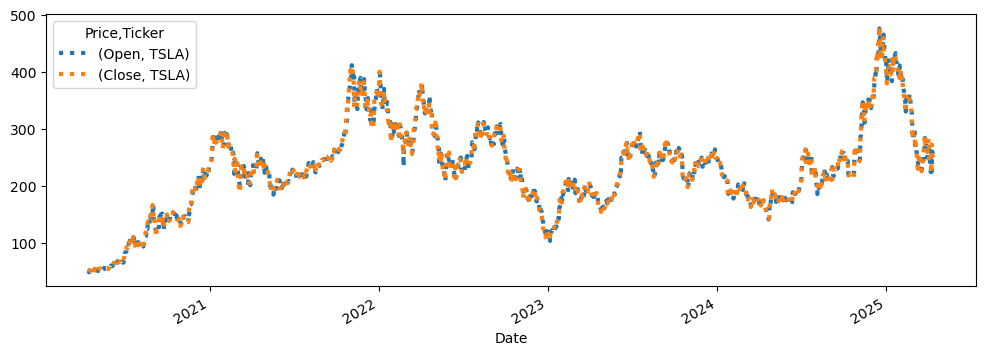

In [20]:
df_tesla[['Open','Close']].plot(figsize=(12,4),ls=':',lw=3)



In [30]:
df_tesla[('Open:10 days rolling', '')] = df_tesla[('Open', 'TSLA')].rolling(window=10,min_periods=1).mean()
df_tesla.head(20)

Price,Close,High,Low,Open,Volume,Open:10 days rolling
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2020-04-15,48.655334,50.208668,47.333332,49.466667,353655000,49.466667
2020-04-16,49.680668,50.630001,47.114666,47.796001,309868500,48.631334
2020-04-17,50.259335,51.663334,49.844002,51.485332,196923000,49.582667
2020-04-20,49.757332,51.037998,47.480667,48.846668,221199000,49.398667
2020-04-21,45.781334,50.222000,44.919334,48.674667,303136500,49.253867
2020-04-22,48.807335,48.933334,45.914001,46.931999,212482500,48.866889
2020-04-23,47.042000,48.933334,46.875332,48.506668,198550500,48.815429
2020-04-24,48.343334,48.715332,46.545334,47.387333,198180000,48.636917


<Axes: xlabel='Date'>

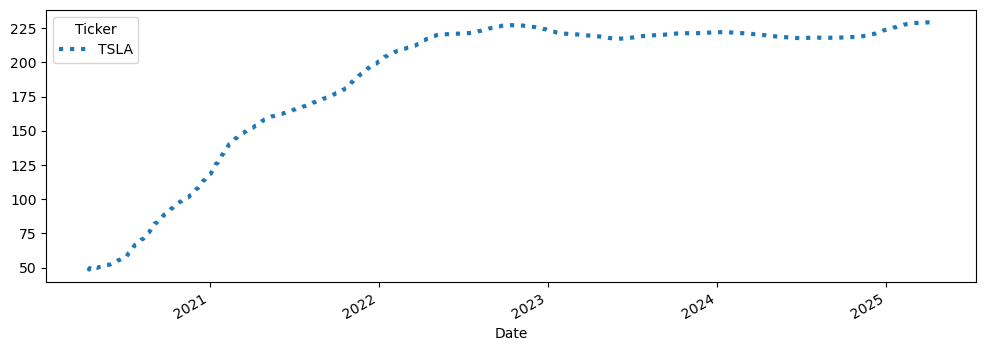

In [31]:
df_tesla['Open'].expanding(min_periods=1).mean().plot(figsize=(12,4),ls=':',lw=3)

In [34]:
df_tesla[('EMA','')]= df_tesla['Open'].ewm(span=10, adjust=False).mean()
df_tesla.head()

Price,Close,High,Low,Open,Volume,Open:10 days rolling,EMA
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,
Date,,,,,,,
2020-04-15,48.655334,50.208668,47.333332,49.466667,353655000,49.466667,49.466667
2020-04-16,49.680668,50.630001,47.114666,47.796001,309868500,48.631334,49.162910
2020-04-17,50.259335,51.663334,49.844002,51.485332,196923000,49.582667,49.585168
2020-04-20,49.757332,51.037998,47.480667,48.846668,221199000,49.398667,49.450896
2020-04-21,45.781334,50.222000,44.919334,48.674667,303136500,49.253867,49.309763
